In [1]:
# Configure path.
import sys; import os
sys.path.append(os.path.abspath('..'))

%matplotlib inline
import numpy as np
import importlib, pickle
import matplotlib.pyplot as plt
from IPython.display import clear_output
plt.style.use('dissertation.mplstyle')

from python import forces, integrators, random_matrix, simulate, densities, plotters, solvers
importlib.reload(forces); importlib.reload(integrators); importlib.reload(random_matrix)
importlib.reload(simulate); importlib.reload(densities); importlib.reload(plotters); importlib.reload(solvers);

---

Re-implementing the HMC but for some $L$ leapfrog steps. First, the explicit method (Chafai and Ferre) but $L>1$. Then looking to see if can write MAIMLA as an integrator step.

Code has been changed to reflect notes: $x$ is current state, $y$ is proposed, $p$ is current momentum, $q$ is proposed.


In [7]:
M = 20; N = 100
beta = 2.0; potential_name = "quartic"; 
dt = 1/N; T = 10.0;
total_steps = int(T/dt);

init = random_matrix.init_quartic_eigenvalues(M, N)
hmc_pipe = simulate.make_hmc_pipeline(N, dt, potential_name, beta)
trajectory = simulate.simulate_dbm(init, total_steps, hmc_pipe)

config = {"burn_in": 0, "snapshot_interval": 5, "track_accepts": True}
info = simulate.analyse_trajectory(trajectory, total_steps, **config)

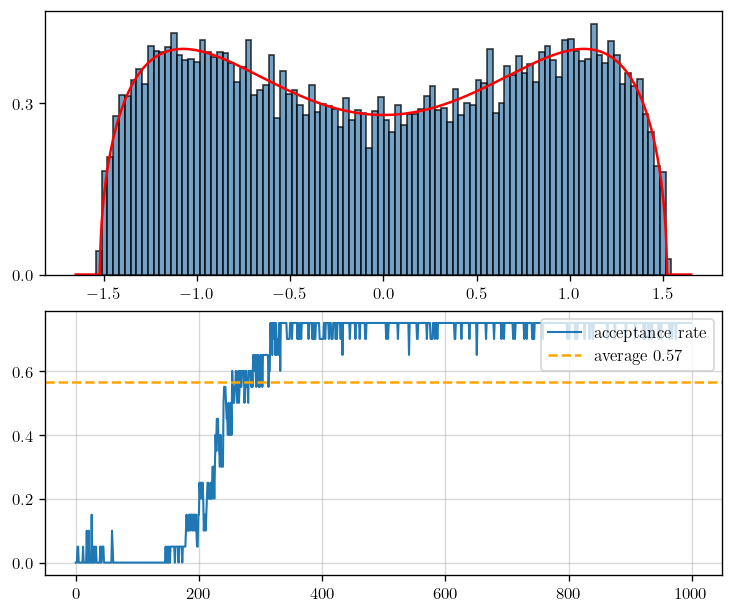

In [8]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize = (6, 5))
plotters.plot_hist(ax1, info["snapshots"], potential_name = "quartic")
plotters.plot_accepts(ax2, info["accepts"])
plt.show()

---
---
---

Side by side comparison running for the same number of steps, with $(\Delta t)_{HMC} = \sqrt{2(\Delta t)_{MALA}}$.

In [45]:
M = 20; N = 100
beta = 2.0; potential_name = "quartic"; 
dt_mala = 1/(4*N) # Tuning to obtain ~30% acceptance.
dt_hmc = np.sqrt(2*dt_mala)
T = 3.0;

total_steps_mala = int(T/dt_mala)
total_steps_hmc = int(T/dt_mala)
L = 1; gamma_N = 1e6

init = random_matrix.init_quartic_eigenvalues(M, N)
mala_pipe = simulate.make_mala_pipeline(N, dt_mala, potential_name, beta)
mala_traj = simulate.simulate_dbm(init, total_steps_mala, mala_pipe)

hmc_pipe = simulate.make_hmc_pipeline(N, dt_hmc, potential_name, beta, L = L, gamma_N = gamma_N)
hmc_traj = simulate.simulate_dbm(init, total_steps_hmc, hmc_pipe)

grid = np.linspace(-2, 2, 1000); F_exact = densities.compute_exact_cdf(N, potential_name, grid)
config_mala = {"burn_in": int(total_steps_mala/2), "snapshot_interval": 5, "track_accepts": True, "track_distance": True,
            "grid": grid, "F_exact": F_exact, "dt": dt_mala}
config_hmc = {"burn_in": int(total_steps_mala/2), "snapshot_interval": 5, "track_accepts": True, "track_distance": True,
            "grid": grid, "F_exact": F_exact, "dt": dt_hmc}
info_mala = simulate.analyse_trajectory(mala_traj, total_steps_mala, **config_mala)
info_hmc = simulate.analyse_trajectory(hmc_traj, total_steps_hmc, **config_hmc)

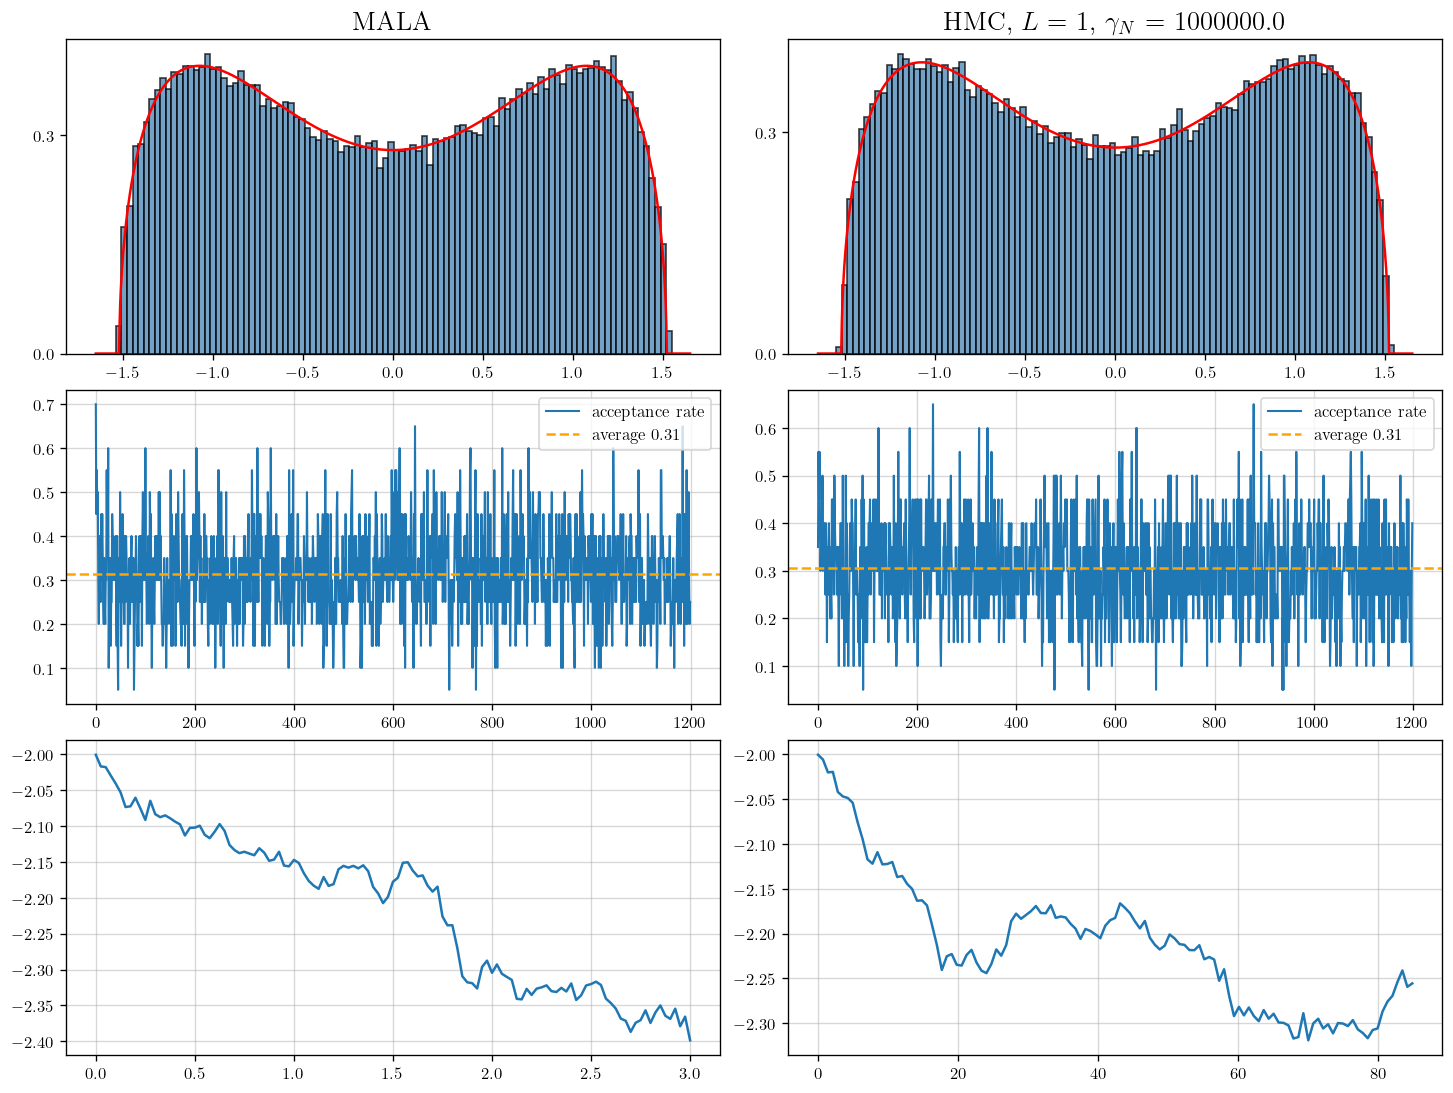

In [46]:
fig, axes = plt.subplots(3, 2, figsize = (12, 9))
ax1, ax2, ax3 = axes[:, 0]

plotters.plot_hist(ax1, info_mala["snapshots"], potential_name = "quartic")
plotters.plot_accepts(ax2, info_mala["accepts"])
plotters.plot_distances(ax3, info_mala)
ax1.set_title("MALA", fontsize = 16, fontweight = "bold")

ax1, ax2, ax3 = axes[:, 1]
plotters.plot_hist(ax1, info_hmc["snapshots"], potential_name = "quartic")
plotters.plot_accepts(ax2, info_hmc["accepts"])
plotters.plot_distances(ax3, info_hmc)
ax1.set_title(rf"HMC, $L$ = {L}, $\gamma_N$ = {gamma_N}", fontsize = 16, fontweight = "bold")

plt.show()

---

In [3]:
M = 50; N = 200
beta = 2.0; potential_name = "quartic"; 
dt_mala = 1/(4*N)
dt_hmc = 0.5*np.sqrt(2*dt_mala)
T = 20.0; gamma_N = 1.0;

total_steps_mala = int(T/dt_mala)
total_steps_hmc = int(T/dt_hmc)

L = int(total_steps_mala//total_steps_hmc)
print(f"MALA total steps: {total_steps_mala} vs HMC: {total_steps_hmc*L}.")

init = random_matrix.init_quartic_eigenvalues(M, N)
mala_pipe = simulate.make_mala_pipeline(N, dt_mala, potential_name, beta)
mala_traj = simulate.simulate_dbm(init, total_steps_mala, mala_pipe)

hmc_pipe = simulate.make_hmc_pipeline(N, dt_hmc, potential_name, beta, L = L, gamma_N = gamma_N)
hmc_traj = simulate.simulate_dbm(init, total_steps_hmc, hmc_pipe)

grid = np.linspace(-2, 2, 1000); F_exact = densities.compute_exact_cdf(N, potential_name, grid)
config_mala = {"burn_in": int(total_steps_mala/2), "snapshot_interval": 5, "track_accepts": True, "track_distance": True,
            "grid": grid, "F_exact": F_exact, "dt": dt_mala}
config_hmc = {"burn_in": int(total_steps_hmc/2), "snapshot_interval": 5, "track_accepts": True, "track_distance": True,
            "grid": grid, "F_exact": F_exact, "dt": dt_hmc}
info_mala = simulate.analyse_trajectory(mala_traj, total_steps_mala, **config_mala)
info_hmc = simulate.analyse_trajectory(hmc_traj, total_steps_hmc, **config_hmc)

MALA total steps: 16000 vs HMC: 16000.


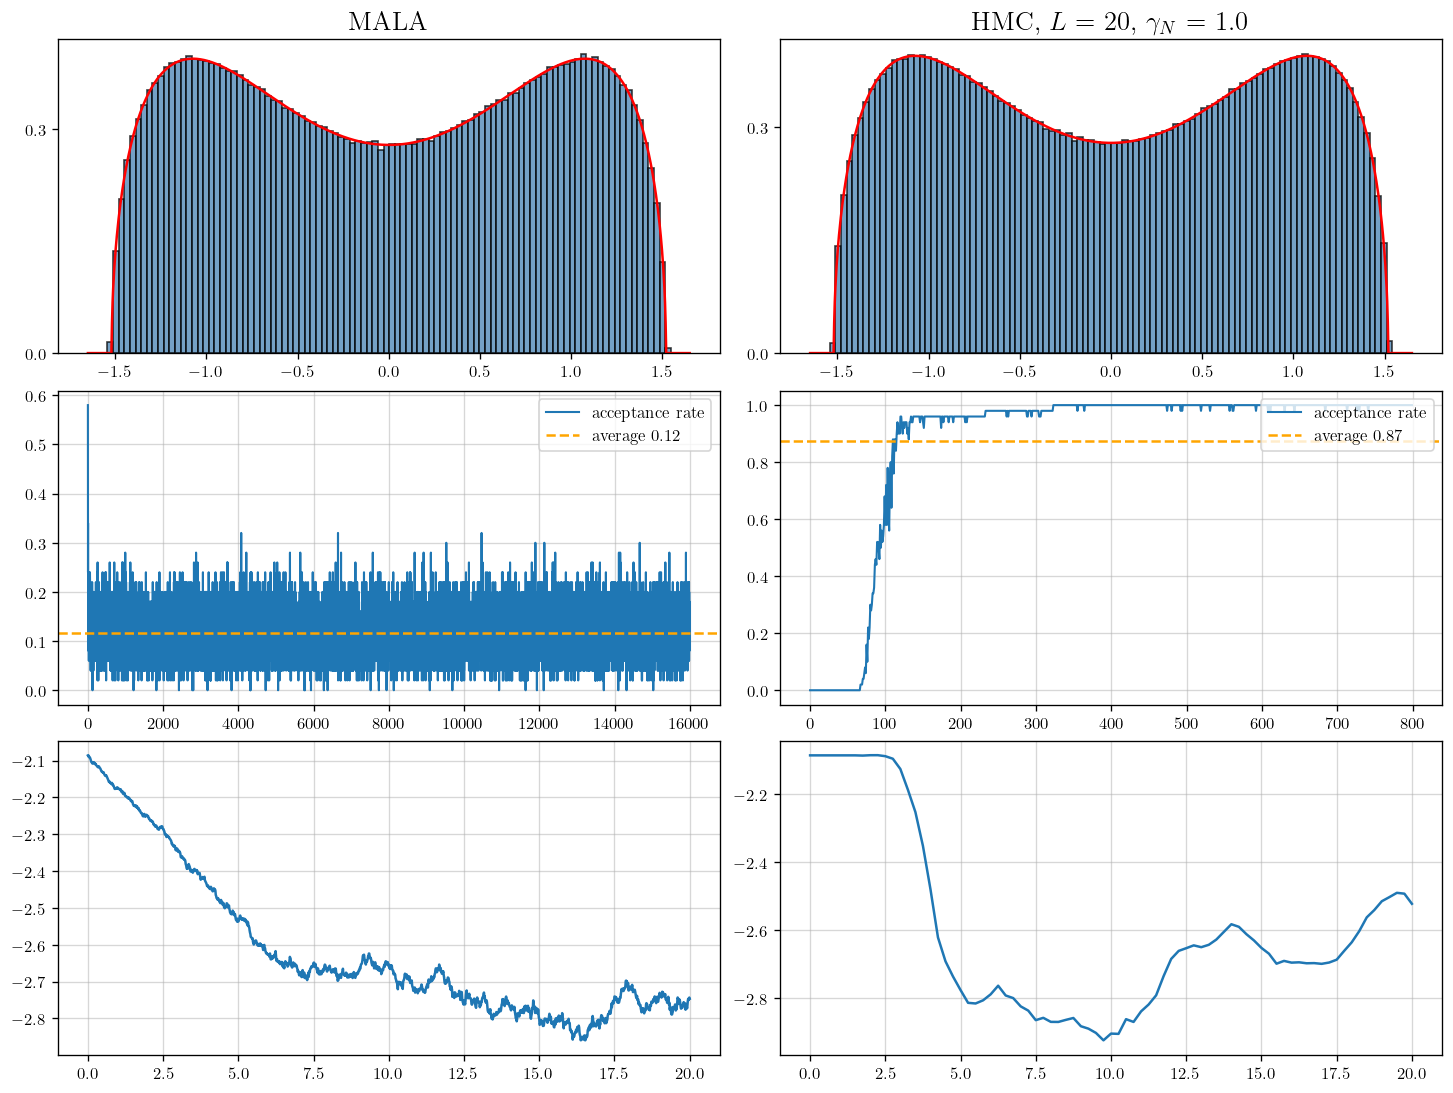

In [4]:
fig, axes = plt.subplots(3, 2, figsize = (12, 9))
ax1, ax2, ax3 = axes[:, 0]

plotters.plot_hist(ax1, info_mala["snapshots"], potential_name = "quartic")
plotters.plot_accepts(ax2, info_mala["accepts"])
plotters.plot_distances(ax3, info_mala)
ax1.set_title("MALA", fontsize = 16, fontweight = "bold")

ax1, ax2, ax3 = axes[:, 1]
plotters.plot_hist(ax1, info_hmc["snapshots"], potential_name = "quartic")
plotters.plot_accepts(ax2, info_hmc["accepts"])
plotters.plot_distances(ax3, info_hmc)
ax1.set_title(rf"HMC, $L$ = {L}, $\gamma_N$ = {gamma_N}", fontsize = 16, fontweight = "bold")

plt.show()

---
---
---
---
---

Some form of adapative step size tuning, but for $L = \mathcal{O}(1), \mathcal{O}(\sqrt{N}), \mathcal{O}(N)$.
- Test $N \in \{50, 70, 100, 150, 200\}$, extend later.
- $L = 10$, $L = \sqrt{N}$, $L = N/2$.
- Set target $0.651$ (Beskos+ paper, 2010).

In [16]:
N_values = [50, 70, 100, 120, 150]; M = 50;
beta = 2.0; potential_name = "quartic"; target = 0.651
burn_steps = 0
kappa = 0.5

final_dts = {"constant": np.zeros_like(N_values, dtype = float), "sqrt": np.zeros_like(N_values, dtype = float), "linear": np.zeros_like(N_values, dtype = float)}
final_accepts = {"constant": np.zeros_like(N_values, dtype = float), "sqrt": np.zeros_like(N_values, dtype = float), "linear": np.zeros_like(N_values, dtype = float)}
eff_results = {"constant": np.zeros_like(N_values, dtype = float), "sqrt": np.zeros_like(N_values, dtype = float), "linear": np.zeros_like(N_values, dtype = float)}
accept_histories = {"constant": np.zeros_like(N_values, dtype = np.ndarray), "sqrt": np.zeros_like(N_values, dtype = np.ndarray), "linear": np.zeros_like(N_values, dtype = np.ndarray)}
dt_histories = {"constant": np.zeros_like(N_values, dtype = np.ndarray), "sqrt": np.zeros_like(N_values, dtype = np.ndarray), "linear": np.zeros_like(N_values, dtype = np.ndarray)}

for j, N in enumerate(N_values):
    clear_output(wait = True)
    print(f"Running for N = {N}.")

    init = random_matrix.init_quartic_eigenvalues(M, N, dt = 0.02, T = 2)
    strategies = {"constant": 10, "linear": int(N//2)}
    
    for name, L in strategies.items():
        dt_init = 1/N
        total_steps = 2000 if (name == "linear") else int(100*N)

        print(f"On N{N} for L {name}, running for {total_steps} steps.")
        accept_history, dt_history = simulate.target_dt("hmc", init, burn_steps, total_steps, potential_name, beta, 
                                    dt_init = dt_init, target = target, L = L, kappa = kappa) 


        final_dts[name][j] = dt_history[-50:].mean(); final_accepts[name][j] = accept_history[-50:].mean()
        accept_histories[name][j] = accept_history; dt_histories[name][j] = dt_history
        eff_results[name][j] = final_dts[name][j]/L

Running for N = 150.
On N150 for L constant, running for 15000 steps.
On N150 for L linear, running for 2000 steps.


[0.6528 0.6496 0.6412 0.6532 0.6448] [0.45754154 0.34692187 0.25716663 0.21727045 0.17958527]
constant -0.8527402470916895 1.1116880575095938
[0.6504 0.6604 0.6452 0.6444 0.6316] [0.88509391 0.82943471 0.80669566 0.77873619 0.73368454]
linear -0.15733402280447936 0.21423013474646335


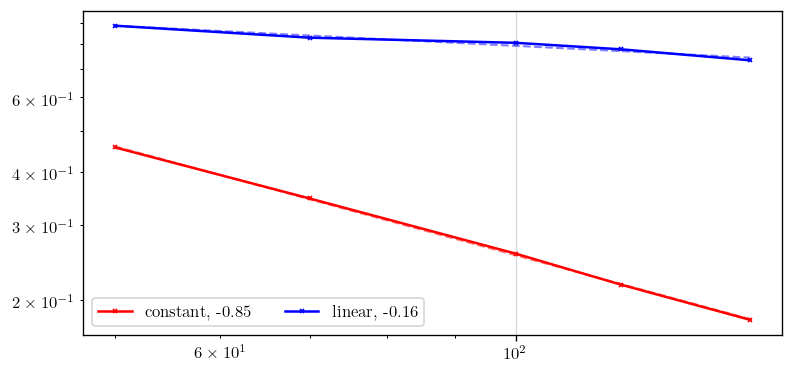

In [33]:
fig, ax = plt.subplots()
colours = ["red", "blue", "green"]

for j, L_type in enumerate(["constant", "linear"]):
    dts = final_dts[L_type]; colour = colours[j]
    log_N = np.log10(N_values); log_dt = np.log10(dts)
    slope, intercept = np.polyfit(log_N, log_dt, 1)
    print(final_accepts[L_type], final_dts[L_type])

    ax.loglog(N_values, dts, label = f"{L_type}, {slope:.2f}", marker = 'x', lw = 1.5, color = colour)
    ax.plot(N_values, 10**(intercept)*N_values**slope, ls = "--", alpha = 0.5, color = colour)
    print(L_type, slope, intercept)

ax.legend(ncols = 2)
plt.show()

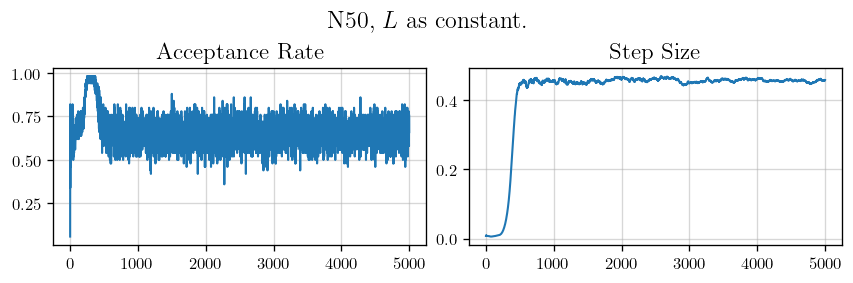

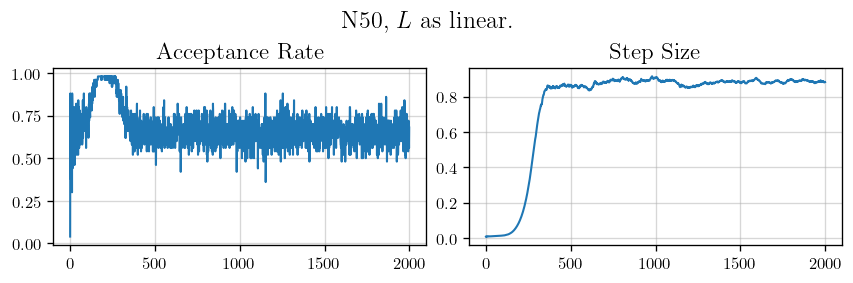

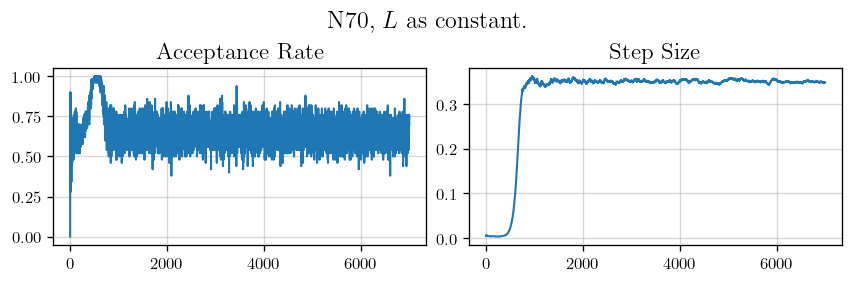

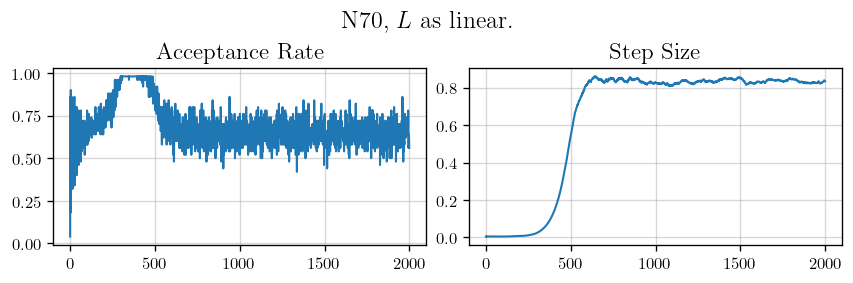

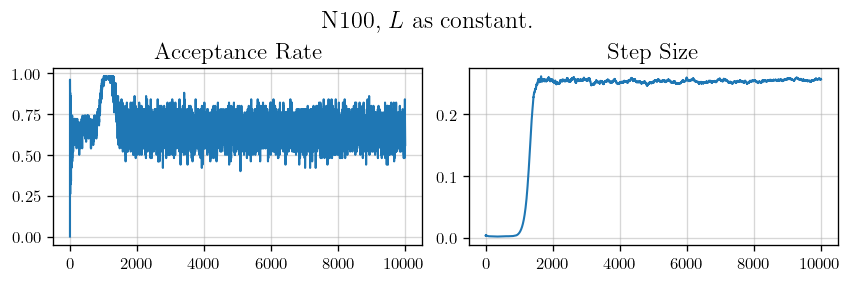

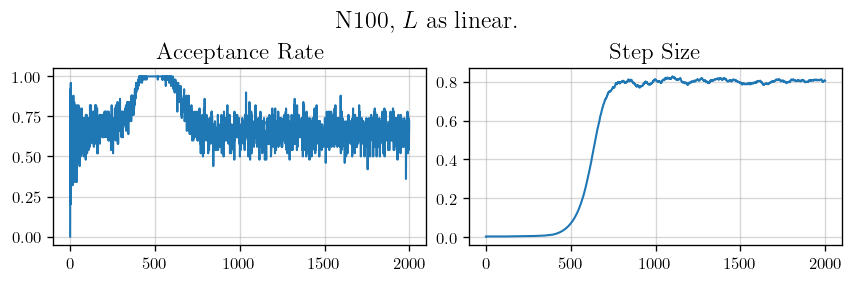

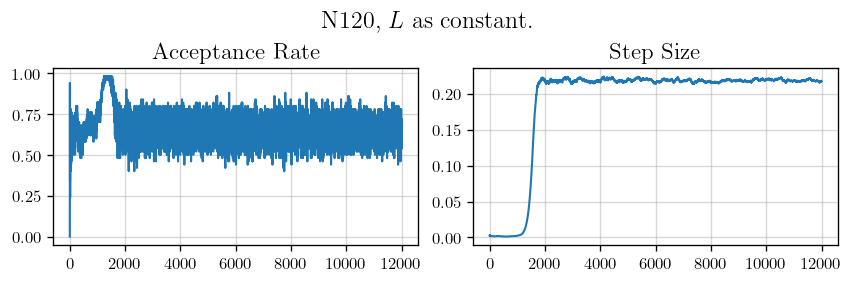

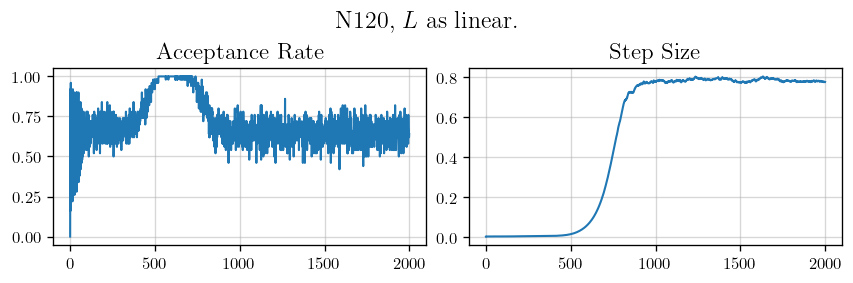

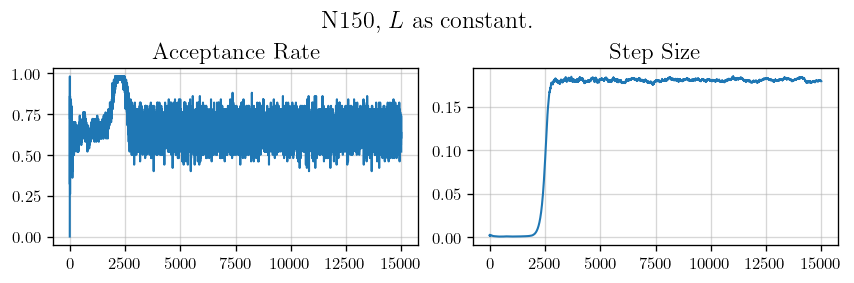

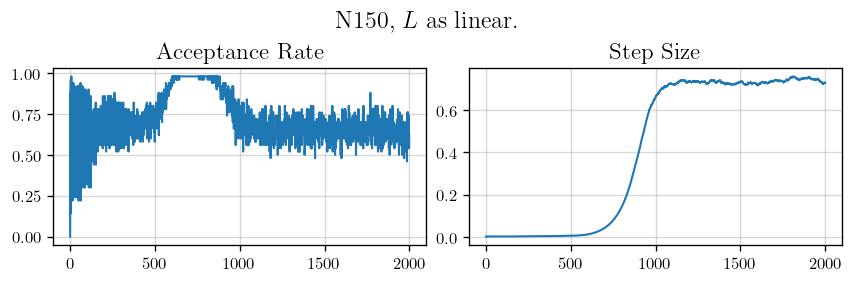

In [17]:
# Trace plots for these Ns.
for j, N in enumerate(N_values):
    for L_type in ["constant", "linear"]:
        fig, axes = plt.subplots(1, 2, figsize = (7, 2.25))
        axes[0].plot(accept_histories[L_type][j])
        axes[1].plot(dt_histories[L_type][j])

        ax1, ax2 = axes
        ax1.set_title("Acceptance Rate", fontsize = 14)
        ax2.set_title("Step Size", fontsize = 14)
        fig.suptitle(rf"N{N}, $L$ as {L_type}.")

        plt.show()

In [ ]:
# Some code for saving the results.
# DO LINEAR FIRST, put kappa back to 0.7, run for 10k steps (N<=200) and for 20k steps (N<=300) and so on.

---
---
---
---
---

In [34]:
slope_constant, intercept_constant = -0.8527402470916895, 1.1116880575095938

In [ ]:
M = 1000; N = 300
beta = 2.0; potential_name = "quartic"; 
dt_hmc = 10**(intercept_constant)*N**(slope_constant)
print(f"Using dt {dt_hmc} - comparison 1/N: {1/N} and 1/4N {1/(4*N)}.")
L = 10; T = 50.0; gamma_N = 1.0;

total_steps_hmc = int(T/dt_hmc)

init = random_matrix.init_quartic_eigenvalues(M, N, dt = 0.02, T = 1)
hmc_pipe = simulate.make_hmc_pipeline(N, dt_hmc, potential_name, beta, L = L, gamma_N = gamma_N)
hmc_traj = simulate.simulate_dbm(init, total_steps_hmc, hmc_pipe)

grid = np.linspace(-2, 2, 1000); F_exact = densities.compute_exact_cdf(N, potential_name, grid)
config_hmc = {"burn_in": int(total_steps_hmc/2), "snapshot_interval": 1, "track_accepts": True, 
            "track_distance": True, "distance_interval": 1,
            "grid": grid, "F_exact": F_exact, "dt": dt_hmc}
info_hmc = simulate.analyse_trajectory(hmc_traj, total_steps_hmc, **config_hmc)

Using dt 0.09984976950710853 - comparison 1/N: 0.0033333333333333335 and 1/4N 0.0008333333333333334.


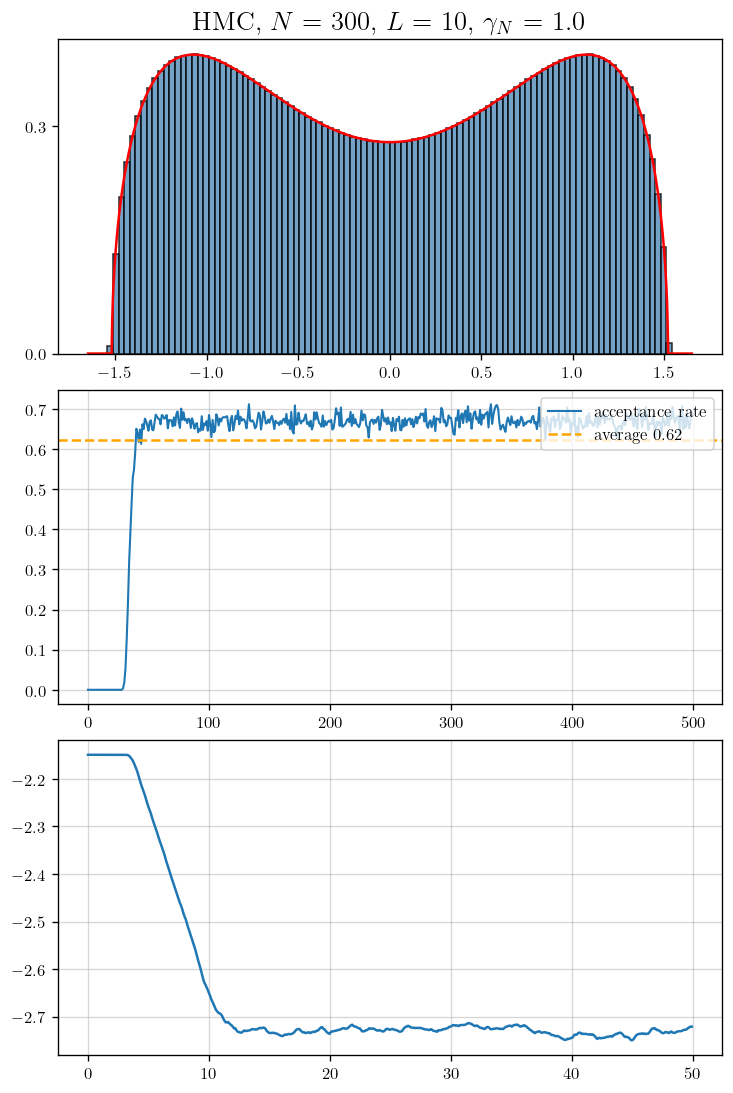

In [52]:
fig, axes = plt.subplots(3, 1, figsize = (6, 9))
ax1, ax2, ax3 = axes 

plotters.plot_hist(ax1, info_hmc["snapshots"], potential_name = "quartic")
plotters.plot_accepts(ax2, info_hmc["accepts"])
plotters.plot_distances(ax3, info_hmc)
ax1.set_title(rf"HMC, $N$ = {N}, $L$ = {L}, $\gamma_N$ = {gamma_N}", fontsize = 16, fontweight = "bold")

plt.show()

---

In [53]:
M = 100; N = 300
beta = 2.0; potential_name = "quartic"; 
dt_hmc = 1.0
L = N; T = 50.0; gamma_N = 1.0;

total_steps_hmc = int(T/dt_hmc)

init = random_matrix.init_quartic_eigenvalues(M, N, dt = 0.02, T = 1)
hmc_pipe = simulate.make_hmc_pipeline(N, dt_hmc, potential_name, beta, L = L, gamma_N = gamma_N)
hmc_traj = simulate.simulate_dbm(init, total_steps_hmc, hmc_pipe)

grid = np.linspace(-2, 2, 1000); F_exact = densities.compute_exact_cdf(N, potential_name, grid)
config_hmc = {"burn_in": int(total_steps_hmc/2), "snapshot_interval": 1, "track_accepts": True, 
            "track_distance": True, "distance_interval": 1,
            "grid": grid, "F_exact": F_exact, "dt": dt_hmc}
info_hmc = simulate.analyse_trajectory(hmc_traj, total_steps_hmc, **config_hmc)

KeyboardInterrupt: 